# Dense periodic n=1 forecast evaluation

## 1. Objective

Evaluate the frozen one-step conditional volatility forecasts from Notebook 04. Forecasts follow delayed-volatility observation: they are issued after $S_{i+1}$ is observed, with $\sigma_i$ known and before delayed observation of $\sigma_{i+1}$.


## 2. Load frozen forecasts

Notebook 05 directly executes only Notebook 04. No baseline, event profile, split, or forecasting model is refitted here.


In [12]:
%%capture
%run "./04_dense_periodic_n1_volatility_forecasting.ipynb"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from statsmodels.tsa.stattools import acf

pd.set_option('display.precision', 6)


## 3. Align frozen forecasts with realised targets

The realised target is joined by transition identifier only after forecast construction.


In [13]:
forecast_columns = ['sigma_forecast_unaware', 'sigma_forecast_parametric', 'sigma_forecast_nonparametric']
forecast_view = test_forecast_table[['i','target_i','t_i','event_i','event_active_i','event_age_i','omega_hat_parametric','omega_hat_nonparametric',*forecast_columns]].copy()
target_view = test_data[['i','target_i','sigma_next','sigma_i','dt_i','epsilon_proxy_i']].copy()
assert not forecast_view['i'].duplicated().any() and not target_view['i'].duplicated().any()
evaluation_table = forecast_view.merge(target_view, on=['i','target_i'], validate='one_to_one')
assert len(evaluation_table) == len(test_forecast_table)


event_free_mask = evaluation_table['event_active_i'].eq(0)
active_mask = evaluation_table['event_active_i'].eq(1)

# All columns except event age must be complete.
required_complete_columns = [c for c in evaluation_table.columns if c != 'event_age_i']
assert evaluation_table[required_complete_columns].notna().all().all()

# Event age is undefined by construction outside event-active windows.
assert evaluation_table.loc[event_free_mask, 'event_age_i'].isna().all()

# Event age must be present for active observations.
assert evaluation_table.loc[active_mask, 'event_age_i'].notna().all()


assert np.isfinite(evaluation_table[['sigma_next',*forecast_columns]].to_numpy()).all()
assert evaluation_table[['sigma_next',*forecast_columns]].gt(0).all().all()
assert np.allclose(evaluation_table.loc[event_free_mask, forecast_columns].to_numpy(), evaluation_table.loc[event_free_mask, forecast_columns[0]].to_numpy()[:,None])
print(f'Evaluation rows: {len(evaluation_table)}; active/event-free: {int(active_mask.sum())}/{int(event_free_mask.sum())}.')


Evaluation rows: 147; active/event-free: 91/56.


## 4. Point-forecast accuracy

Errors use $e_{i,m}=\sigma_{i+1}-\widehat\sigma_{i+1,m}$: positive values mean underestimation.


,subset,model,observation_count,MAE,RMSE,bias,median_absolute_error
0,All test,Event-unaware,147,0.000869,0.001091,0.000511,0.000778
1,All test,Parametric event-aware,147,0.000701,0.000872,0.000191,0.000629
2,All test,Non-parametric event-aware,147,0.000671,0.000861,0.000140,0.000534
3,Active,Event-unaware,91,0.001015,0.001228,0.000787,0.000933
4,Active,Parametric event-aware,91,0.000742,0.000902,0.000271,0.000660
5,Active,Non-parametric event-aware,91,0.000695,0.000883,0.000188,0.000606
6,Event-free,Event-unaware,56,0.000633,0.000823,0.000061,0.000527
7,Event-free,Parametric event-aware,56,0.000633,0.000823,0.000061,0.000527
8,Event-free,Non-parametric event-aware,56,0.000633,0.000823,0.000061,0.000527


,subset,model,MAE_gain_percent,RMSE_gain_percent
0,All test,Parametric event-aware,19.405311,20.051999
1,All test,Non-parametric event-aware,22.776716,21.126892
2,Active,Parametric event-aware,26.857856,26.552508
3,Active,Non-parametric event-aware,31.524038,28.051118


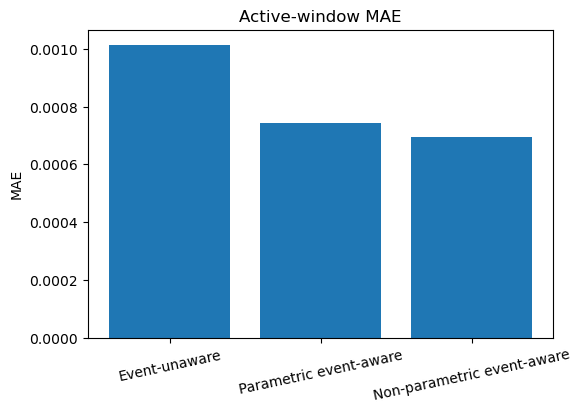

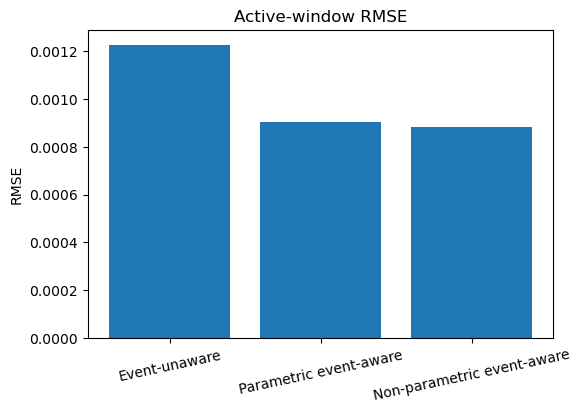

In [14]:
model_labels = {'sigma_forecast_unaware':'Event-unaware','sigma_forecast_parametric':'Parametric event-aware','sigma_forecast_nonparametric':'Non-parametric event-aware'}
for col in forecast_columns:
    evaluation_table[f'error_{col}'] = evaluation_table['sigma_next'] - evaluation_table[col]

def accuracy_rows(frame, subset):
    rows=[]
    for col,label in model_labels.items():
        err=frame[f'error_{col}']
        rows.append({'subset':subset,'model':label,'observation_count':len(frame),'MAE':err.abs().mean(),'RMSE':np.sqrt(np.mean(err**2)),'bias':err.mean(),'median_absolute_error':err.abs().median()})
    return rows
accuracy_table=pd.DataFrame(accuracy_rows(evaluation_table,'All test')+accuracy_rows(evaluation_table.loc[active_mask],'Active')+accuracy_rows(evaluation_table.loc[event_free_mask],'Event-free'))
display(accuracy_table)

gain_rows=[]
for subset in ['All test','Active']:
    base=accuracy_table.query("subset == @subset and model == 'Event-unaware'").iloc[0]
    for model in ['Parametric event-aware','Non-parametric event-aware']:
        row=accuracy_table.query('subset == @subset and model == @model').iloc[0]
        gain_rows.append({'subset':subset,'model':model,'MAE_gain_percent':100*(1-row.MAE/base.MAE),'RMSE_gain_percent':100*(1-row.RMSE/base.RMSE)})
relative_gain_table=pd.DataFrame(gain_rows); display(relative_gain_table)
active_accuracy=accuracy_table.query("subset == 'Active'")
for metric,title in [('MAE','Active-window MAE'),('RMSE','Active-window RMSE')]:
    fig,ax=plt.subplots(figsize=(6,4)); ax.bar(active_accuracy['model'],active_accuracy[metric]); ax.set(title=title,ylabel=metric); ax.set_ylim(bottom=0); plt.xticks(rotation=12); plt.show()


## 5. Accuracy by event age

Age-level results are diagnostic: each configured age has few test observations and is not a separate formal hypothesis test.


,event_age,model,observation_count,MAE,RMSE,bias,mean_realised_sigma_next,mean_forecast
0,0,Event-unaware,7,0.001292,0.001454,0.001292,0.250913,0.249621
1,0,Parametric event-aware,7,0.000630,0.000694,0.000245,0.250913,0.250667
2,0,Non-parametric event-aware,7,0.000684,0.000747,0.000367,0.250913,0.250546
3,1,Event-unaware,7,0.001039,0.001319,0.001039,0.251523,0.250484
4,1,Parametric event-aware,7,0.000566,0.000817,0.000128,0.251523,0.251395
5,1,Non-parametric event-aware,7,0.000536,0.000883,0.000356,0.251523,0.251168
6,2,Event-unaware,7,0.001605,0.001681,0.001605,0.252737,0.251132
7,2,Parametric event-aware,7,0.000813,0.000953,0.000813,0.252737,0.251923
8,2,Non-parametric event-aware,7,0.000631,0.000754,0.000568,0.252737,0.252169
9,3,Event-unaware,7,0.001146,0.001241,0.001146,0.253720,0.252574


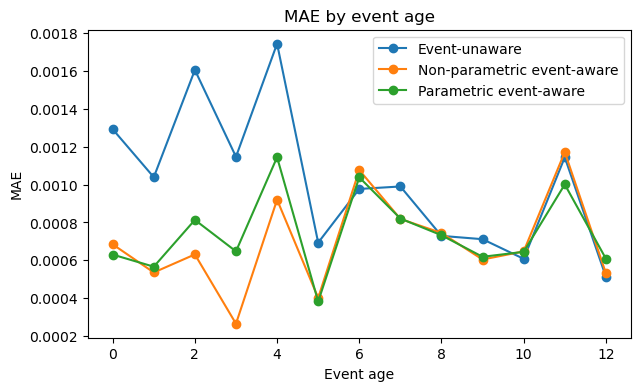

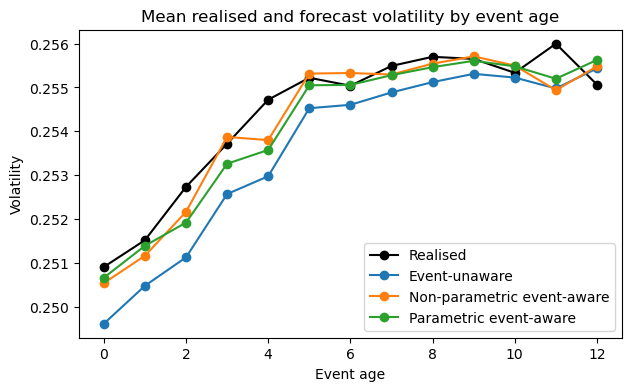

In [15]:
age_rows=[]
for age in event_transition_ages:
    frame=evaluation_table.loc[evaluation_table.event_age_i.eq(age)]
    for col,label in model_labels.items():
        err=frame[f'error_{col}']; age_rows.append({'event_age':age,'model':label,'observation_count':len(frame),'MAE':err.abs().mean(),'RMSE':np.sqrt(np.mean(err**2)),'bias':err.mean(),'mean_realised_sigma_next':frame.sigma_next.mean(),'mean_forecast':frame[col].mean()})
age_accuracy_table=pd.DataFrame(age_rows); display(age_accuracy_table)
fig,ax=plt.subplots(figsize=(7,4))
for label,frame in age_accuracy_table.groupby('model'): ax.plot(frame.event_age,frame.MAE,marker='o',label=label)
ax.set(title='MAE by event age',xlabel='Event age',ylabel='MAE'); ax.legend(); plt.show()
fig,ax=plt.subplots(figsize=(7,4)); realised=age_accuracy_table.groupby('event_age').mean_realised_sigma_next.first(); ax.plot(realised.index,realised,marker='o',color='black',label='Realised')
for label,frame in age_accuracy_table.groupby('model'): ax.plot(frame.event_age,frame.mean_forecast,marker='o',label=label)
ax.set(title='Mean realised and forecast volatility by event age',xlabel='Event age',ylabel='Volatility'); ax.legend(); plt.show()


## 6. Event-cycle paired block bootstrap

Complete response windows are the independent resampling blocks; each resample is paired across models. Both the observed bootstrap comparison and resampling use only complete event cycles. Main active-window accuracy tables retain all active rows. The proportion of positive improvements is bootstrap support, not a classical p-value; fewer than three complete cycles causes a documented skip rather than failure.


In [16]:
active_eval = evaluation_table.loc[active_mask].copy()
active_eval['cycle_id'] = active_eval['i'] - active_eval['event_age_i']
complete_cycles = []
for cycle_id, frame in active_eval.groupby('cycle_id'):
    if len(frame) == len(event_transition_ages) and set(frame['event_age_i']) == set(event_transition_ages):
        complete_cycles.append(frame.sort_values('event_age_i'))
complete_active_eval = pd.concat(complete_cycles, ignore_index=True) if complete_cycles else pd.DataFrame(columns=active_eval.columns)
bootstrap_seed = 20260805
bootstrap_rng = np.random.default_rng(bootstrap_seed)
requested_bootstrap_replications = 5000
bootstrap_performed = len(complete_cycles) >= 3

def metric_difference(frame, metric, aware_col):
    unaware_error = frame['error_sigma_forecast_unaware']
    aware_error = frame[f'error_{aware_col}']
    if metric == 'MAE':
        return unaware_error.abs().mean() - aware_error.abs().mean()
    return np.sqrt(np.mean(unaware_error ** 2)) - np.sqrt(np.mean(aware_error ** 2))

if bootstrap_performed:
    observed = [
        (metric, aware, metric_difference(complete_active_eval, metric, aware))
        for metric in ['MAE', 'RMSE']
        for aware in ['sigma_forecast_parametric', 'sigma_forecast_nonparametric']
    ]
    draws = {(metric, aware): [] for metric, aware, _ in observed}
    for _ in range(requested_bootstrap_replications):
        selected = bootstrap_rng.integers(0, len(complete_cycles), size=len(complete_cycles))
        sample = pd.concat([complete_cycles[j] for j in selected], ignore_index=True)
        for metric, aware, _ in observed:
            draws[(metric, aware)].append(metric_difference(sample, metric, aware))
    bootstrap_rows = []
    for metric, aware, value in observed:
        values = np.asarray(draws[(metric, aware)])
        bootstrap_rows.append({
            'metric': metric, 'model': model_labels[aware],
            'observed_difference': value, 'bootstrap_mean_difference': values.mean(),
            'percentile_2_5': np.quantile(values, .025), 'percentile_97_5': np.quantile(values, .975),
            'bootstrap_support_positive': np.mean(values > 0),
            'complete_cycles': len(complete_cycles), 'replications': requested_bootstrap_replications,
        })
    bootstrap_table = pd.DataFrame(bootstrap_rows)
else:
    bootstrap_table = pd.DataFrame([{
        'message': 'Fewer than three complete event-response cycles are available; block bootstrap skipped.',
        'complete_cycles': len(complete_cycles), 'replications': 0,
    }])
print(f'Complete active rows used for observed bootstrap differences: {len(complete_active_eval)}.')
display(bootstrap_table)


Complete active rows used for observed bootstrap differences: 91.


,metric,model,observed_difference,bootstrap_mean_difference,percentile_2_5,percentile_97_5,bootstrap_support_positive,complete_cycles,replications
0,MAE,Parametric event-aware,0.000273,0.000272,0.000191,0.000349,1.0,7,5000
1,MAE,Non-parametric event-aware,0.000320,0.000319,0.000232,0.000413,1.0,7,5000
2,RMSE,Parametric event-aware,0.000326,0.000324,0.000236,0.000389,1.0,7,5000
3,RMSE,Non-parametric event-aware,0.000344,0.000343,0.000250,0.000433,1.0,7,5000


## 7. Mean calibration regressions

These supplementary OLS regressions use HAC covariance with a horizon-derived lag. Forecast ranges are narrow and the test sample is modest.


,subset,model,intercept,intercept_se,slope,slope_se,joint_wald_statistic,joint_p_value,nobs
0,All test,Event-unaware,0.005183,0.003495,0.981557,0.013802,30.147899,2.840971e-07,147
1,All test,Parametric event-aware,0.003301,0.002978,0.987739,0.011667,7.363600,2.517761e-02,147
2,All test,Non-parametric event-aware,0.003623,0.003086,0.986270,0.012048,4.414920,1.099796e-01,147
3,Active,Event-unaware,0.003698,0.004287,0.988521,0.016695,106.154072,8.890704e-24,91
4,Active,Parametric event-aware,0.000239,0.003668,1.000126,0.014291,14.287453,7.898032e-04,91
5,Active,Non-parametric event-aware,0.000515,0.003887,0.998715,0.015123,6.955257,3.088056e-02,91


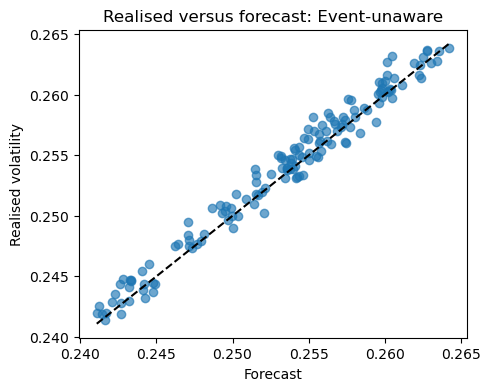

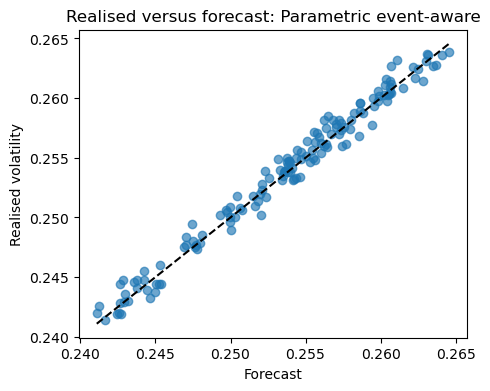

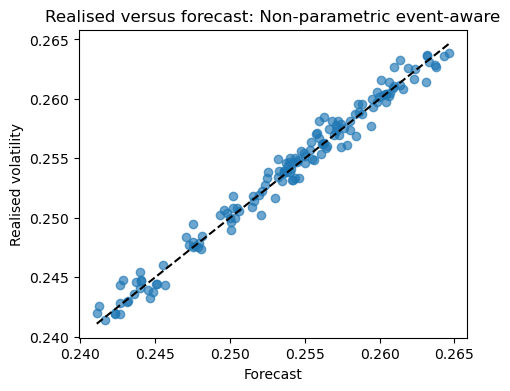

In [17]:
hac_lag=min(response_horizon_steps,max(0,len(evaluation_table)-2))
cal_rows=[]
for subset,frame in [('All test',evaluation_table),('Active',active_eval)]:
    for col,label in model_labels.items():
        fit=sm.OLS(frame.sigma_next,sm.add_constant(frame[col],has_constant='add')).fit(cov_type='HAC',cov_kwds={'maxlags':hac_lag})
        wald=fit.wald_test((np.eye(2), np.array([0.0, 1.0])), scalar=True)
        cal_rows.append({'subset':subset,'model':label,'intercept':fit.params['const'],'intercept_se':fit.bse['const'],'slope':fit.params[col],'slope_se':fit.bse[col],'joint_wald_statistic':float(wald.statistic),'joint_p_value':float(wald.pvalue),'nobs':int(fit.nobs)})
calibration_table=pd.DataFrame(cal_rows); display(calibration_table)
for col,label in model_labels.items():
    fig,ax=plt.subplots(figsize=(5,4)); ax.scatter(evaluation_table[col],evaluation_table.sigma_next,alpha=.65); lo=min(evaluation_table[col].min(),evaluation_table.sigma_next.min()); hi=max(evaluation_table[col].max(),evaluation_table.sigma_next.max()); ax.plot([lo,hi],[lo,hi],'k--'); ax.set(title=f'Realised versus forecast: {label}',xlabel='Forecast',ylabel='Realised volatility'); plt.show()


## 8. Training-based conditional variance and prediction intervals

The event-free training OLS residual variance is plug-in conditional variance. Event weights scale it through $\omega_{i+1}$; no test errors tune interval widths.


,subset,model,nominal_coverage,empirical_coverage,coverage_error,average_interval_width,median_interval_width,mean_interval_score
0,All test,Event-unaware,0.50,0.421769,-0.078231,0.001218,0.001218,0.002849
1,Active,Event-unaware,0.50,0.340659,-0.159341,0.001218,0.001218,0.003293
2,Event-free,Event-unaware,0.50,0.553571,0.053571,0.001218,0.001218,0.002129
3,All test,Event-unaware,0.80,0.680272,-0.119728,0.002315,0.002315,0.003952
4,Active,Event-unaware,0.80,0.582418,-0.217582,0.002315,0.002315,0.004536
5,Event-free,Event-unaware,0.80,0.839286,0.039286,0.002315,0.002315,0.003003
6,All test,Event-unaware,0.95,0.904762,-0.045238,0.003541,0.003541,0.005140
7,Active,Event-unaware,0.95,0.868132,-0.081868,0.003541,0.003541,0.006038
8,Event-free,Event-unaware,0.95,0.964286,0.014286,0.003541,0.003541,0.003679
9,All test,Parametric event-aware,0.50,0.489796,-0.010204,0.001220,0.001220,0.002217


,model,nominal_coverage,negative_lower_bounds
0,Event-unaware,0.50,0
1,Event-unaware,0.80,0
2,Event-unaware,0.95,0
3,Parametric event-aware,0.50,0
4,Parametric event-aware,0.80,0
5,Parametric event-aware,0.95,0
6,Non-parametric event-aware,0.50,0
7,Non-parametric event-aware,0.80,0
8,Non-parametric event-aware,0.95,0


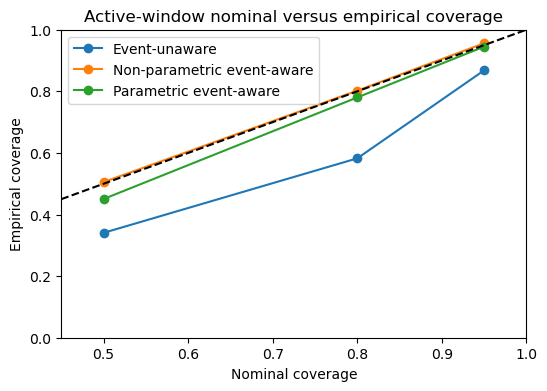

In [18]:
baseline_residual_variance=float(ols_baseline.mse_resid)
variance_columns={'sigma_forecast_unaware':'variance_hat_unaware','sigma_forecast_parametric':'variance_hat_parametric','sigma_forecast_nonparametric':'variance_hat_nonparametric'}
evaluation_table['variance_hat_unaware']=baseline_residual_variance
evaluation_table['variance_hat_parametric']=evaluation_table.omega_hat_parametric*baseline_residual_variance
evaluation_table['variance_hat_nonparametric']=evaluation_table.omega_hat_nonparametric*baseline_residual_variance
assert np.isfinite(evaluation_table[list(variance_columns.values())].to_numpy()).all() and evaluation_table[list(variance_columns.values())].gt(0).all().all()
nominal_levels=np.array([.50,.80,.95]); interval_rows=[]; lower_bound_counts=[]
def interval_score(y,l,u,alpha): return (u-l)+(2/alpha)*(l-y)*(y<l)+(2/alpha)*(y-u)*(y>u)
for col,label in model_labels.items():
    sd=np.sqrt(evaluation_table[variance_columns[col]])
    for nominal in nominal_levels:
        alpha=1-nominal; z=stats.norm.ppf(1-alpha/2); lower=evaluation_table[col]-z*sd; upper=evaluation_table[col]+z*sd
        evaluation_table[f'{col}_lower_{int(nominal*100)}']=lower; evaluation_table[f'{col}_upper_{int(nominal*100)}']=upper
        lower_bound_counts.append({'model':label,'nominal_coverage':nominal,'negative_lower_bounds':int((lower<0).sum())})
        for subset,mask in [('All test',pd.Series(True,index=evaluation_table.index)),('Active',active_mask),('Event-free',event_free_mask)]:
            y=evaluation_table.loc[mask,'sigma_next']; l=lower.loc[mask]; u=upper.loc[mask]; cover=((y>=l)&(y<=u)); score=interval_score(y,l,u,alpha)
            interval_rows.append({'subset':subset,'model':label,'nominal_coverage':nominal,'empirical_coverage':cover.mean(),'coverage_error':cover.mean()-nominal,'average_interval_width':(u-l).mean(),'median_interval_width':(u-l).median(),'mean_interval_score':score.mean()})
interval_table=pd.DataFrame(interval_rows); lower_bounds_table=pd.DataFrame(lower_bound_counts); display(interval_table); display(lower_bounds_table)
fig,ax=plt.subplots(figsize=(6,4));
for label,frame in interval_table.query("subset == 'Active'").groupby('model'): ax.plot(frame.nominal_coverage,frame.empirical_coverage,marker='o',label=label)
ax.plot([0,1],[0,1],'k--'); ax.set(title='Active-window nominal versus empirical coverage',xlabel='Nominal coverage',ylabel='Empirical coverage',xlim=(.45,1),ylim=(0,1)); ax.legend(); plt.show()


## 9. Standardised-residual diagnostics

Diagnostics assess centring, scale, tails, and serial dependence; small-sample normality tests are intentionally omitted.


,subset,model,count,mean,std,median,skewness,excess_kurtosis
0,All test,Event-unaware,147,0.565196,1.071480,0.533110,0.000984,-0.351163
1,Active,Event-unaware,91,0.871262,1.049020,0.962137,-0.154939,-0.387792
2,All test,Parametric event-aware,147,0.210791,0.944580,0.205072,-0.016010,-0.270480
3,Active,Parametric event-aware,91,0.298762,0.955778,0.324213,-0.025000,-0.392869
4,All test,Non-parametric event-aware,147,0.154367,0.942299,0.114190,0.062002,-0.082026
5,Active,Non-parametric event-aware,91,0.207616,0.958929,0.141841,0.103981,-0.121283


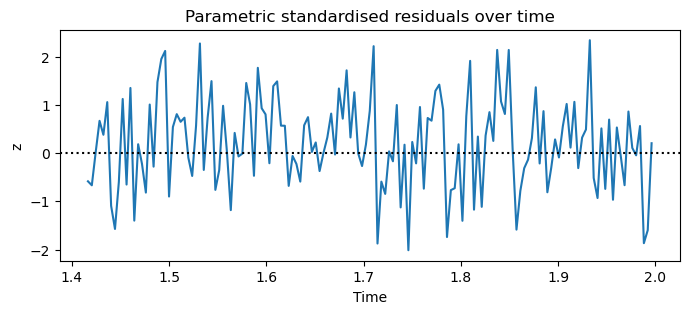

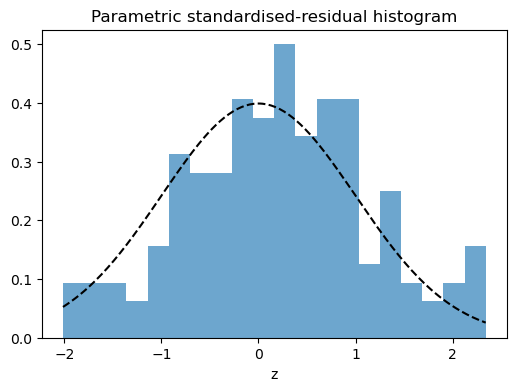

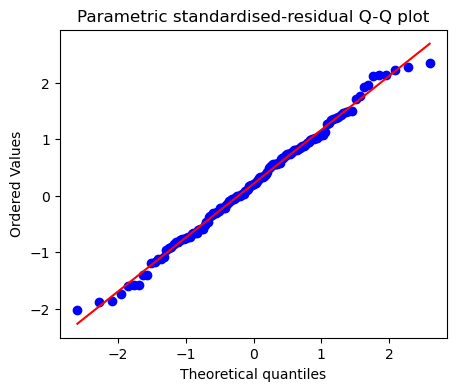

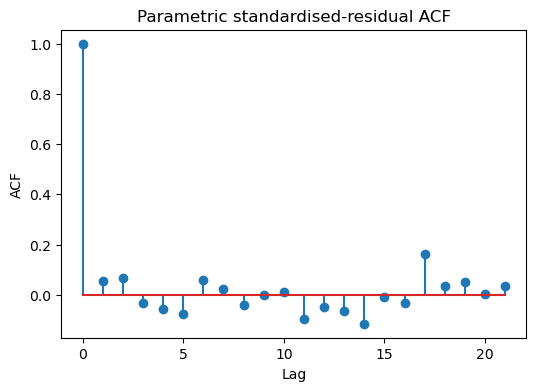

In [19]:
resid_rows=[]
for col,label in model_labels.items():
    z=evaluation_table[f'error_{col}']/np.sqrt(evaluation_table[variance_columns[col]]); evaluation_table[f'z_{col}']=z
    for subset,mask in [('All test',pd.Series(True,index=evaluation_table.index)),('Active',active_mask)]:
        vals=z.loc[mask]; resid_rows.append({'subset':subset,'model':label,'count':len(vals),'mean':vals.mean(),'std':vals.std(ddof=1),'median':vals.median(),'skewness':stats.skew(vals,bias=False),'excess_kurtosis':stats.kurtosis(vals,bias=False)})
residual_summary=pd.DataFrame(resid_rows); display(residual_summary)
diagnostic_col='sigma_forecast_parametric'; z=evaluation_table[f'z_{diagnostic_col}']; lags=min(max(1,event_period_steps),len(z)-1)
fig,ax=plt.subplots(figsize=(8,3)); ax.plot(evaluation_table.t_i,z); ax.axhline(0,color='black',linestyle=':'); ax.set(title='Parametric standardised residuals over time',xlabel='Time',ylabel='z'); plt.show()
fig,ax=plt.subplots(figsize=(6,4)); ax.hist(z,bins=20,density=True,alpha=.65); x=np.linspace(z.min(),z.max(),200); ax.plot(x,stats.norm.pdf(x),'k--'); ax.set(title='Parametric standardised-residual histogram',xlabel='z'); plt.show()
fig,ax=plt.subplots(figsize=(5,4)); stats.probplot(z,dist='norm',plot=ax); ax.set_title('Parametric standardised-residual Q-Q plot'); plt.show()
fig,ax=plt.subplots(figsize=(6,4)); a=acf(z,nlags=lags,fft=False); ax.stem(range(len(a)),a); ax.set(title='Parametric standardised-residual ACF',xlabel='Lag',ylabel='ACF'); plt.show()


## 10. Known-DGP synthetic reference

This diagnostic reference is accessed only after fitted-model evaluation. It is not a deployable competitor and never affects fitted forecasts, intervals, or selection.


In [20]:
# True simulator quantities are accessed only now, after all fitted primary tables exist.
omega_column=next(name for name in ['omega_next','omega'] if name in transitions.columns)
true_omega_by_i=transitions.set_index('i')[omega_column]
dgp=evaluation_table[['i','sigma_i','dt_i','epsilon_proxy_i','sigma_next']].copy(); dgp['true_omega']=dgp['i'].map(true_omega_by_i)
kappa=model_params['kappa']; theta=model_params['theta']; nu=model_params['nu_0']; rho=model_params['rho_0']
dgp['conditional_mean_DGP']=np.sqrt(dgp.true_omega)*(dgp.sigma_i+kappa*(theta-dgp.sigma_i)*dgp.dt_i+nu*rho*dgp.epsilon_proxy_i)
dgp['conditional_variance_DGP']=dgp.true_omega*(nu**2)*(1-rho**2)*dgp.dt_i
assert dgp[['true_omega','conditional_mean_DGP','conditional_variance_DGP']].gt(0).all().all()
dgp_error=dgp.sigma_next-dgp.conditional_mean_DGP
reference_rows=[]
for nominal in nominal_levels:
 alpha=1-nominal; z=stats.norm.ppf(1-alpha/2); width=2*z*np.sqrt(dgp.conditional_variance_DGP); lower=dgp.conditional_mean_DGP-width/2; upper=dgp.conditional_mean_DGP+width/2; reference_rows.append({'nominal_coverage':nominal,'empirical_coverage':((dgp.sigma_next>=lower)&(dgp.sigma_next<=upper)).mean(),'average_interval_width':width.mean()})
known_dgp_table=pd.DataFrame(reference_rows); known_dgp_point=pd.DataFrame([{'model':'Known-DGP synthetic reference','MAE':dgp_error.abs().mean(),'RMSE':np.sqrt(np.mean(dgp_error**2)),'bias':dgp_error.mean()}])
comparison=accuracy_table.query("subset == 'All test'")[['model','MAE','RMSE','bias']].copy(); comparison=pd.concat([comparison,known_dgp_point],ignore_index=True); display(comparison); display(known_dgp_table)


,model,MAE,RMSE,bias
0,Event-unaware,0.000869,0.001091,0.000511
1,Parametric event-aware,0.000701,0.000872,0.000191
2,Non-parametric event-aware,0.000671,0.000861,0.000140
3,Known-DGP synthetic reference,0.000653,0.000820,0.000048


,nominal_coverage,empirical_coverage,average_interval_width
0,0.50,0.523810,0.001196
1,0.80,0.829932,0.002272
2,0.95,0.952381,0.003475


## 11. Illustrative event-response window

The 95% parametric interval is an untuned Gaussian plug-in interval.


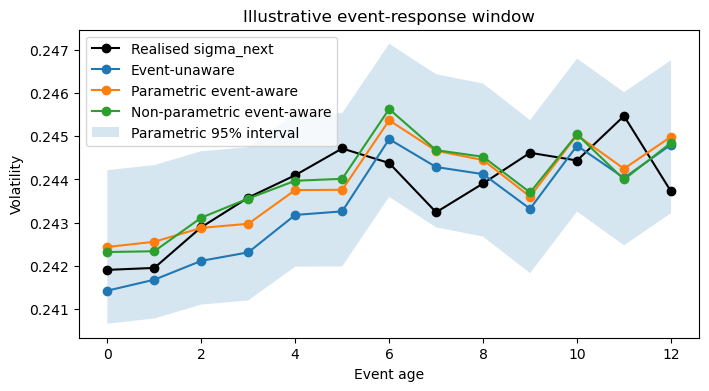

In [21]:
window=active_eval.loc[active_eval.cycle_id.eq(active_eval.cycle_id.iloc[0])].sort_values('event_age_i')
fig,ax=plt.subplots(figsize=(8,4)); ax.plot(window.event_age_i,window.sigma_next,marker='o',color='black',label='Realised sigma_next')
for col,label in model_labels.items(): ax.plot(window.event_age_i,window[col],marker='o',label=label)
lower=evaluation_table.set_index('i').loc[window.i,'sigma_forecast_parametric_lower_95']; upper=evaluation_table.set_index('i').loc[window.i,'sigma_forecast_parametric_upper_95']; ax.fill_between(window.event_age_i,lower,upper,alpha=.18,label='Parametric 95% interval'); ax.set(title='Illustrative event-response window',xlabel='Event age',ylabel='Volatility'); ax.legend(); plt.show()


## 12. Final findings and limitations

The following findings are generated from the completed tables, not hard-coded values. They are diagnostic rather than definitive: this experiment has limited independent event cycles, dependent observations within responses, small age-level samples, Gaussian plug-in intervals without parameter-estimation uncertainty, a known calendar and directly observed synthetic volatility under delayed observation, and the current dense periodic non-overlapping n=1 benchmark only.


In [22]:
active_results = accuracy_table.query("subset == 'Active'").set_index('model')
active_gains = relative_gain_table.query("subset == 'Active'").set_index('model')
active_coverage = interval_table.query("subset == 'Active'").pivot(index='model', columns='nominal_coverage', values='empirical_coverage')
active_calibration = calibration_table.query("subset == 'Active'").set_index('model')
parametric_name = 'Parametric event-aware'
nonparametric_name = 'Non-parametric event-aware'
print(f"Event weighting substantially improves active-window MAE/RMSE versus unaware: parametric {active_gains.loc[parametric_name, 'MAE_gain_percent']:.2f}%/{active_gains.loc[parametric_name, 'RMSE_gain_percent']:.2f}%, non-parametric {active_gains.loc[nonparametric_name, 'MAE_gain_percent']:.2f}%/{active_gains.loc[nonparametric_name, 'RMSE_gain_percent']:.2f}%.")
mae_winner = active_results['MAE'].loc[[parametric_name, nonparametric_name]].idxmin(); rmse_winner = active_results['RMSE'].loc[[parametric_name, nonparametric_name]].idxmin()
print(f'Within active windows, {mae_winner} has lower MAE and {rmse_winner} has lower RMSE; neither is described as universally superior.')
print('Event-free forecasts are identical by construction, so all-row gains are diluted relative to active-window gains.')
for model in [parametric_name, nonparametric_name]:
    coverage_values = ', '.join(f'{int(level*100)}%={active_coverage.loc[model, level]:.3f}' for level in sorted(active_coverage.columns))
    print(f'{model} active interval coverage: {coverage_values}; compare this with the unaware model using the coverage table.')
for model in [parametric_name, nonparametric_name]:
    p_value = active_calibration.loc[model, 'joint_p_value']
    print(f'{model} active joint calibration Wald p-value={p_value:.4g}; formal mean calibration remains imperfect when this joint null is rejected.')
if bootstrap_performed:
    for _, row in bootstrap_table.iterrows(): print(f"Bootstrap {row['metric']} {row['model']}: observed improvement={row['observed_difference']:.6g}, 95% CI [{row['percentile_2_5']:.6g}, {row['percentile_97_5']:.6g}], support={row['bootstrap_support_positive']:.3f}.")
    print(f'Bootstrap support for improvement uses {len(complete_cycles)} complete non-onverlapping event-response cycles.')
else:
    print(bootstrap_table.loc[0, 'message'])
print(f"Known-DGP synthetic reference (not deployable) has MAE={known_dgp_point.loc[0,'MAE']:.6g}, RMSE={known_dgp_point.loc[0,'RMSE']:.6g}; remaining difference reflects irreducible eta noise and fitted-model limitations.")
print('Age-level results are diagnostic rather than definitive; the Gaussian plug-in intervals omit OLS and event-profile estimation uncertainty.')


Event weighting substantially improves active-window MAE/RMSE versus unaware: parametric 26.86%/26.55%, non-parametric 31.52%/28.05%.
Within active windows, Non-parametric event-aware has lower MAE and Non-parametric event-aware has lower RMSE; neither is described as universally superior.
Event-free forecasts are identical by construction, so all-row gains are diluted relative to active-window gains.
Parametric event-aware active interval coverage: 50%=0.451, 80%=0.780, 95%=0.945; compare this with the unaware model using the coverage table.
Non-parametric event-aware active interval coverage: 50%=0.505, 80%=0.802, 95%=0.956; compare this with the unaware model using the coverage table.
Parametric event-aware active joint calibration Wald p-value=0.0007898; formal mean calibration remains imperfect when this joint null is rejected.
Non-parametric event-aware active joint calibration Wald p-value=0.03088; formal mean calibration remains imperfect when this joint null is rejected.
Boots